# 07 — Anomaly Detection: Suspicious Claim Intelligence
### Healthcare Provider Risk Intelligence System — Unsupervised Layer

> **Loads:** `master_cleaned.csv`, `provider_risk_predictions.csv`, `patient_risk_predictions.csv`

---
## Table of Contents
1. [Business Understanding](#1)
2. [Detection Level Decision](#2)
3. [Feature Engineering — Claim-Level Table](#3)
4. [Feature Selection & Scaling](#4)
5. [Baseline Statistical Outliers (Z-Score & IQR)](#5)
6. [Model 1 — Isolation Forest](#6)
7. [Model 2 — Local Outlier Factor](#7)
8. [Agreement Analysis — IF + LOF Consensus](#8)
9. [Anomaly Investigation — Profile of Flagged Claims](#9)
10. [Suspicious Claim Score (0–100)](#10)
11. [Investigation Buckets](#11)
12. [Validation Without Labels](#12)
13. [Save Results](#13)
14. [Summary](#14)


---
## 1. Business Understanding <a id='1'></a>

In [1]:
print("""
BUSINESS UNDERSTANDING
======================
Goal:
  Identify abnormal healthcare claims and entities using
  unsupervised learning — no fraud labels required.

Business Value:
  Prioritize manual audits on the most suspicious claims.
  Rather than reviewing 200,000 claims, investigators can
  focus on the top-scoring Critical bucket first.

Why anomaly detection complements the risk models:
  The provider and patient risk models (Notebooks 05–06) answer:
    "How risky is this entity based on known patterns?"

  Anomaly detection answers:
    "Which claims behave differently from everything else?"
    "We have never seen this pattern before."

  Insurance companies already have risk rules.
  The real value comes from discovering the unknown.

Architecture:
  Provider Risk Model (05)  ─┐
  Patient Risk Model  (06)  ─┼──> Anomaly Detection (this notebook)
  master_cleaned.csv        ─┘         ↓
                              Suspicious Claim Score
                                        ↓
                              Investigation Buckets
                                        ↓
                              LLM Investigator (08)
""")



BUSINESS UNDERSTANDING
Goal:
  Identify abnormal healthcare claims and entities using
  unsupervised learning — no fraud labels required.

Business Value:
  Prioritize manual audits on the most suspicious claims.
  Rather than reviewing 200,000 claims, investigators can
  focus on the top-scoring Critical bucket first.

Why anomaly detection complements the risk models:
  The provider and patient risk models (Notebooks 05–06) answer:
    "How risky is this entity based on known patterns?"

  Anomaly detection answers:
    "Which claims behave differently from everything else?"
    "We have never seen this pattern before."

  Insurance companies already have risk rules.
  The real value comes from discovering the unknown.

Architecture:
  Provider Risk Model (05)  ─┐
  Patient Risk Model  (06)  ─┼──> Anomaly Detection (this notebook)
  master_cleaned.csv        ─┘         ↓
                              Suspicious Claim Score
                                        ↓
                  

---
## 2. Detection Level Decision <a id='2'></a>

In [2]:
print("""
DETECTION LEVEL: CLAIM-LEVEL
============================
Three options were considered:

  Option A: Provider-Level  (1 row = 1 provider, 5,000 rows)
  Option B: Patient-Level   (1 row = 1 patient,  49,096 rows)
  Option C: Claim-Level     (1 row = 1 claim,   200,000 rows)  <-- CHOSEN

Reason:
  Fraud occurs at the CLAIM level.
  A provider or patient can have both legitimate and fraudulent
  claims simultaneously. Collapsing to provider/patient level
  would average out the anomalous claims and lose signal.

  Claim-level detection also allows us to:
    - Attach provider risk (from Notebook 05) as a feature
    - Attach patient risk  (from Notebook 06) as a feature
    - Generate a per-claim suspicious score for investigators
""")



DETECTION LEVEL: CLAIM-LEVEL
Three options were considered:

  Option A: Provider-Level  (1 row = 1 provider, 5,000 rows)
  Option B: Patient-Level   (1 row = 1 patient,  49,096 rows)
  Option C: Claim-Level     (1 row = 1 claim,   200,000 rows)  <-- CHOSEN

Reason:
  Fraud occurs at the CLAIM level.
  A provider or patient can have both legitimate and fraudulent
  claims simultaneously. Collapsing to provider/patient level
  would average out the anomalous claims and lose signal.

  Claim-level detection also allows us to:
    - Attach provider risk (from Notebook 05) as a feature
    - Attach patient risk  (from Notebook 06) as a feature
    - Generate a per-claim suspicious score for investigators



---
## 3. Feature Engineering — Claim-Level Table <a id='3'></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "figure.dpi": 100,
})
print("Libraries loaded.")


Libraries loaded.


In [4]:
# Load source tables
master_df  = pd.read_csv("..\\cleaned_data\master_cleaned.csv", parse_dates=['claim_date','payment_date'])
prov_pred  = pd.read_csv("..\\risk_predict_data\provider_risk_predictions.csv")
pat_pred   = pd.read_csv("..\\risk_predict_data\patient_risk_predictions.csv")

print("master_df  :", master_df.shape)
print("prov_pred  :", prov_pred.shape)
print("pat_pred   :", pat_pred.shape)


master_df  : (200000, 24)
prov_pred  : (5000, 18)
pat_pred   : (49096, 12)


In [5]:
# Build claim-level feature table
# Join: master <- provider predicted risk & specialty ratio <- patient predicted risk

claim_df = master_df[[
    'claim_id','patient_id','provider_id','claim_date',
    'claim_amount','status','payment_amount','payment_ratio',
    'settlement_days','duplicate_claim_flag','month_end_flag','specialty'
]].copy()

# Provider-level signals (predicted risk + specialty billing ratio)
claim_df = claim_df.merge(
    prov_pred[['provider_id','predicted_risk_score','provider_vs_specialty_ratio',
               'provider_rejection_rate','provider_claim_count']].rename(
        columns={'predicted_risk_score': 'predicted_provider_risk'}),
    on='provider_id', how='left'
)

# Patient-level signals (predicted risk)
claim_df = claim_df.merge(
    pat_pred[['patient_id','predicted_risk_score']].rename(
        columns={'predicted_risk_score': 'predicted_patient_risk'}),
    on='patient_id', how='left'
)

# Engineer additional anomaly-sensitive features
claim_df['payment_gap']        = claim_df['claim_amount'] - claim_df['payment_amount'].fillna(0)
claim_df['early_payment_flag'] = (claim_df['settlement_days'].fillna(0) < 0).astype(int)
claim_df['late_payment_flag']  = (claim_df['settlement_days'].fillna(0) > 365).astype(int)
claim_df['rejected_flag']      = (claim_df['status'] == 'Rejected').astype(int)

print(f"claim_df shape: {claim_df.shape}")
print()
print("Early payments (settlement_days < 0):", claim_df['early_payment_flag'].sum(),
      f"({claim_df['early_payment_flag'].mean()*100:.1f}%)")
print("Late payments  (settlement_days > 365):", claim_df['late_payment_flag'].sum(),
      f"({claim_df['late_payment_flag'].mean()*100:.1f}%)")
print()
print("Null rates in feature columns:")
feature_preview = ['claim_amount','payment_ratio','settlement_days','duplicate_claim_flag',
                   'predicted_provider_risk','predicted_patient_risk','provider_vs_specialty_ratio']
print(claim_df[feature_preview].isna().mean().mul(100).round(1).to_string())


claim_df shape: (200000, 21)

Early payments (settlement_days < 0): 74890 (37.4%)
Late payments  (settlement_days > 365): 18865 (9.4%)

Null rates in feature columns:
claim_amount                    0.0
payment_ratio                  25.0
settlement_days                25.0
duplicate_claim_flag            0.0
predicted_provider_risk         0.0
predicted_patient_risk          0.0
provider_vs_specialty_ratio     0.0


---
## 4. Feature Selection & Scaling <a id='4'></a>

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Feature set: claim behaviour + provider intelligence + patient intelligence
# Identifiers (claim_id, patient_id, provider_id, provider_name) excluded.
ANOMALY_FEATURES = [
    # Claim behaviour
    'claim_amount',
    'payment_ratio',
    'settlement_days',
    'duplicate_claim_flag',
    'month_end_flag',
    'early_payment_flag',
    'late_payment_flag',
    'rejected_flag',
    # Provider intelligence (from Notebook 05)
    'predicted_provider_risk',
    'provider_vs_specialty_ratio',
    # Patient intelligence (from Notebook 06)
    'predicted_patient_risk',
]

print("Anomaly detection features:", ANOMALY_FEATURES)
print()

# Impute then scale -- Isolation Forest is robust to scaling
# but LOF requires it.
X_raw = claim_df[ANOMALY_FEATURES].copy()

imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_imputed = imputer.fit_transform(X_raw)
X_scaled  = scaler.fit_transform(X_imputed)

print(f"Feature matrix shape (scaled): {X_scaled.shape}")
print(f"Any NaN after impute+scale: {np.isnan(X_scaled).any()}")


Anomaly detection features: ['claim_amount', 'payment_ratio', 'settlement_days', 'duplicate_claim_flag', 'month_end_flag', 'early_payment_flag', 'late_payment_flag', 'rejected_flag', 'predicted_provider_risk', 'provider_vs_specialty_ratio', 'predicted_patient_risk']

Feature matrix shape (scaled): (200000, 11)
Any NaN after impute+scale: False


---
## 5. Baseline Statistical Outliers (Z-Score & IQR) <a id='5'></a>

Business validation step before any ML model runs.

=== BASELINE STATISTICAL OUTLIERS ===
claim_amount  Z-Score outliers (|z|>3) : 1,167 (0.6%)
settlement_days IQR outliers           : 0 (0.0%)



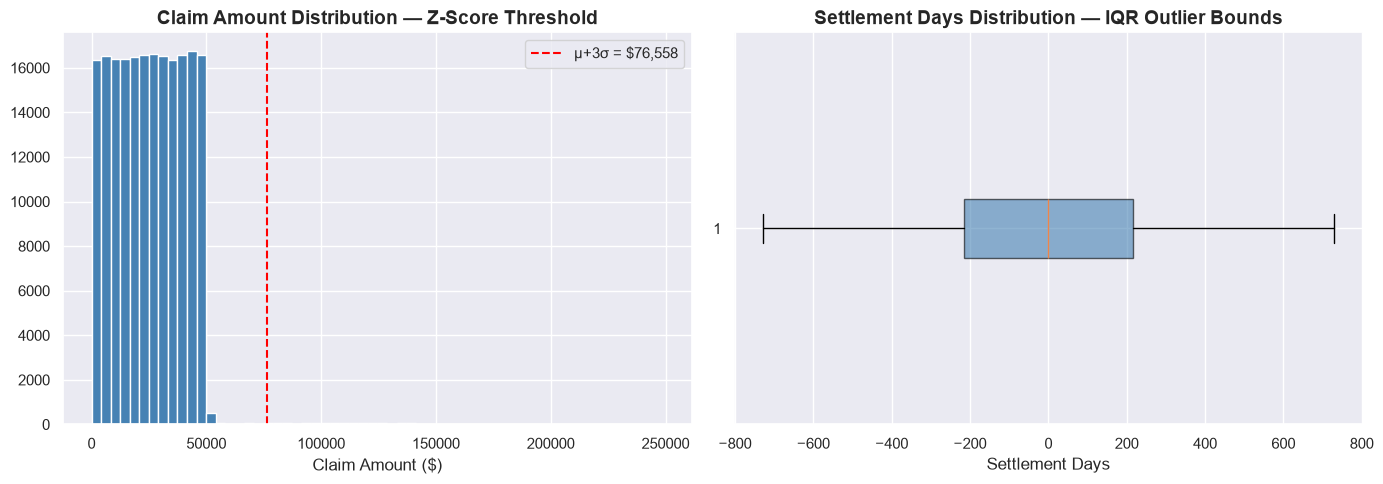

In [7]:
from scipy import stats

# Z-Score outliers for claim_amount (|z| > 3)
z_scores = np.abs(stats.zscore(claim_df['claim_amount'].dropna()))
z_mask   = pd.Series(False, index=claim_df.index)
z_mask[claim_df['claim_amount'].dropna().index] = z_scores > 3
claim_df['zscore_outlier'] = z_mask.astype(int)

# IQR outliers for settlement_days (paid claims only)
paid = claim_df['settlement_days'].dropna()
Q1, Q3 = paid.quantile(0.25), paid.quantile(0.75)
IQR    = Q3 - Q1
iqr_mask = pd.Series(False, index=claim_df.index)
iqr_mask[paid.index] = (paid < Q1 - 1.5*IQR) | (paid > Q3 + 1.5*IQR)
claim_df['iqr_outlier'] = iqr_mask.astype(int)

print("=== BASELINE STATISTICAL OUTLIERS ===")
print(f"claim_amount  Z-Score outliers (|z|>3) : {claim_df['zscore_outlier'].sum():,} "
      f"({claim_df['zscore_outlier'].mean()*100:.1f}%)")
print(f"settlement_days IQR outliers           : {claim_df['iqr_outlier'].sum():,} "
      f"({claim_df['iqr_outlier'].mean()*100:.1f}%)")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(claim_df['claim_amount'], bins=60, color='steelblue', edgecolor='white')
for thr in [claim_df['claim_amount'].mean() + 3*claim_df['claim_amount'].std()]:
    axes[0].axvline(thr, color='red', linestyle='--', label=f'μ+3σ = ${thr:,.0f}')
axes[0].set_title("Claim Amount Distribution — Z-Score Threshold")
axes[0].set_xlabel("Claim Amount ($)")
axes[0].legend()

axes[1].boxplot(paid, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title("Settlement Days Distribution — IQR Outlier Bounds")
axes[1].set_xlabel("Settlement Days")

plt.tight_layout()
plt.savefig("..\\anomaly_detect_images\s5_baseline_outliers.png", dpi=100, bbox_inches='tight')
plt.show()


---
## 6. Model 1 — Isolation Forest <a id='6'></a>

In [8]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,   # expect ~5% suspicious claims
    random_state=42,
    n_jobs=-1
)

claim_df['if_label']        = iso.fit_predict(X_scaled)   # 1=normal, -1=anomaly
claim_df['if_anomaly_score'] = iso.decision_function(X_scaled)  # lower = more anomalous
claim_df['if_flag']         = (claim_df['if_label'] == -1).astype(int)

n_flagged = claim_df['if_flag'].sum()
print(f"Isolation Forest — flagged: {n_flagged:,} / {len(claim_df):,} "
      f"({n_flagged/len(claim_df)*100:.1f}%)")
print()
print("Anomaly score stats:")
print(claim_df['if_anomaly_score'].describe().to_string())


Isolation Forest — flagged: 10,000 / 200,000 (5.0%)

Anomaly score stats:
count    200000.000000
mean          0.117208
std           0.060031
min          -0.175714
25%           0.078642
50%           0.131276
75%           0.162499
max           0.210097


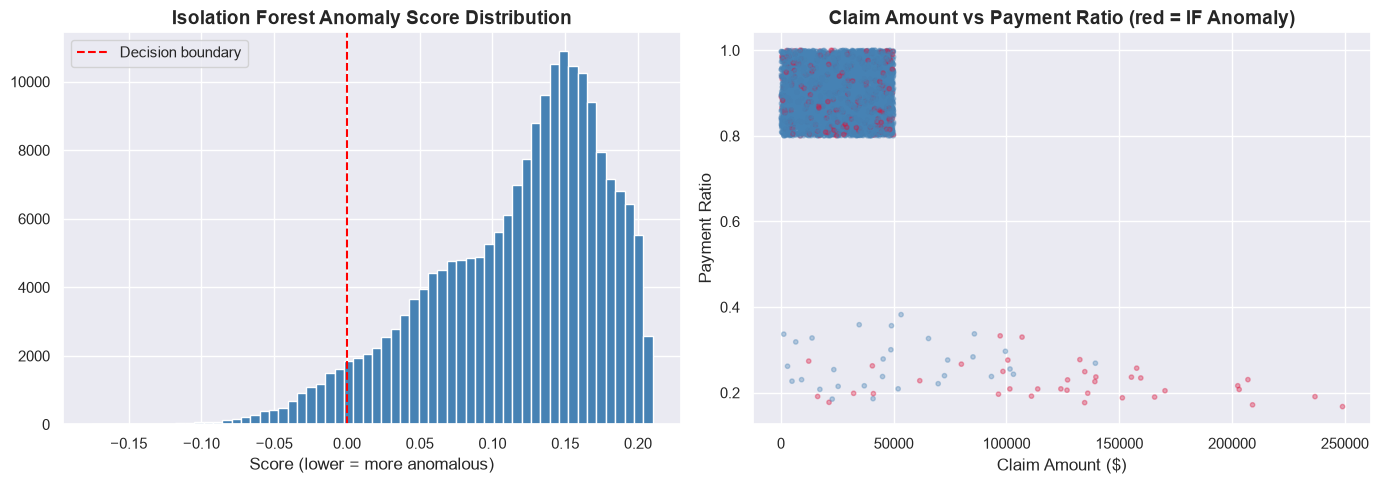

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(claim_df['if_anomaly_score'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', label='Decision boundary')
axes[0].set_title("Isolation Forest Anomaly Score Distribution")
axes[0].set_xlabel("Score (lower = more anomalous)")
axes[0].legend()

sample = claim_df.sample(min(8000, len(claim_df)), random_state=42)
c_map  = sample['if_flag'].map({0:'steelblue', 1:'crimson'})
axes[1].scatter(sample['claim_amount'], sample['payment_ratio'],
                c=c_map, alpha=0.35, s=10)
axes[1].set_title("Claim Amount vs Payment Ratio (red = IF Anomaly)")
axes[1].set_xlabel("Claim Amount ($)")
axes[1].set_ylabel("Payment Ratio")

plt.tight_layout()
plt.savefig("..\\anomaly_detect_images\s6_isolation_forest.png", dpi=100, bbox_inches='tight')
plt.show()


---
## 7. Model 2 — Local Outlier Factor <a id='7'></a>

LOF detects **local** anomalies — claims that are unusual within their neighborhood
(e.g., a claim that is normal nationally but suspicious within its specialty group).
It uses the full scaled matrix, same as Isolation Forest.


Local Outlier Factor — flagged: 10,000 / 200,000 (5.0%)


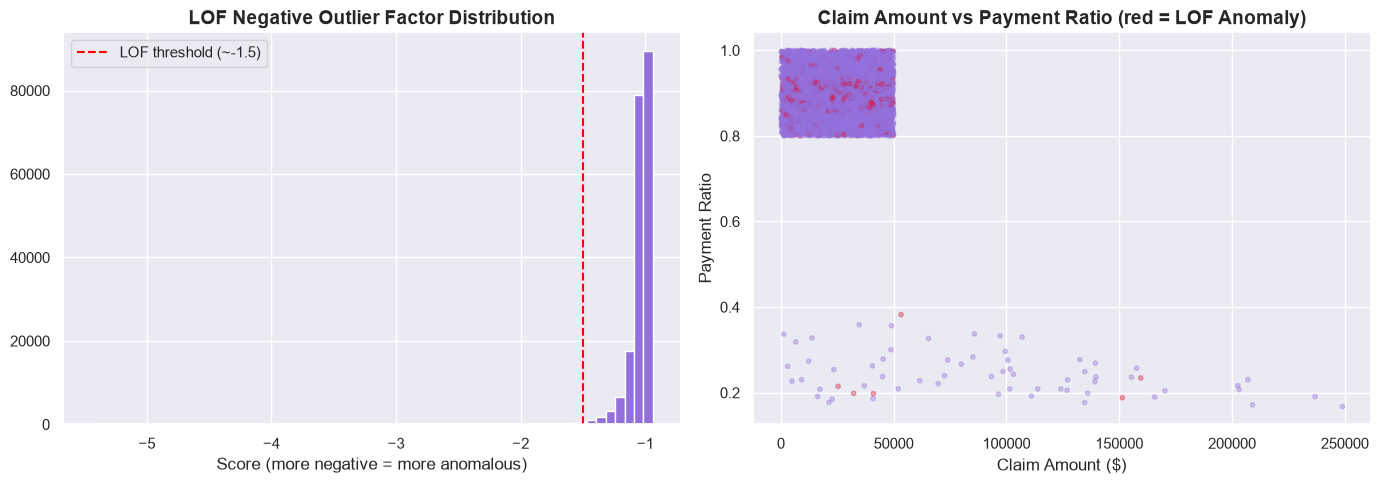

In [10]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    n_jobs=-1
)

claim_df['lof_label']         = lof.fit_predict(X_scaled)   # 1=normal, -1=anomaly
claim_df['lof_anomaly_score'] = lof.negative_outlier_factor_  # more negative = more anomalous
claim_df['lof_flag']          = (claim_df['lof_label'] == -1).astype(int)

n_lof = claim_df['lof_flag'].sum()
print(f"Local Outlier Factor — flagged: {n_lof:,} / {len(claim_df):,} "
      f"({n_lof/len(claim_df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(claim_df['lof_anomaly_score'], bins=60, color='mediumpurple', edgecolor='white')
axes[0].axvline(-1.5, color='red', linestyle='--', label='LOF threshold (~-1.5)')
axes[0].set_title("LOF Negative Outlier Factor Distribution")
axes[0].set_xlabel("Score (more negative = more anomalous)")
axes[0].legend()

c_map2 = sample['claim_id'].map(
    claim_df.set_index('claim_id')['lof_flag']).map({0:'mediumpurple', 1:'crimson'})
axes[1].scatter(sample['claim_amount'], sample['payment_ratio'],
                c=c_map2, alpha=0.35, s=10)
axes[1].set_title("Claim Amount vs Payment Ratio (red = LOF Anomaly)")
axes[1].set_xlabel("Claim Amount ($)")
axes[1].set_ylabel("Payment Ratio")

plt.tight_layout()
plt.savefig("..\\anomaly_detect_images\s7_lof.png", dpi=100, bbox_inches='tight')
plt.show()


---
## 8. Agreement Analysis — IF + LOF Consensus <a id='8'></a>

=== Agreement Table ===
consensus
Normal              181355
IF Only               8645
LOF Only              8645
BOTH (Strongest)      1355

Strongest candidates (flagged by BOTH): 1355 (0.7%)


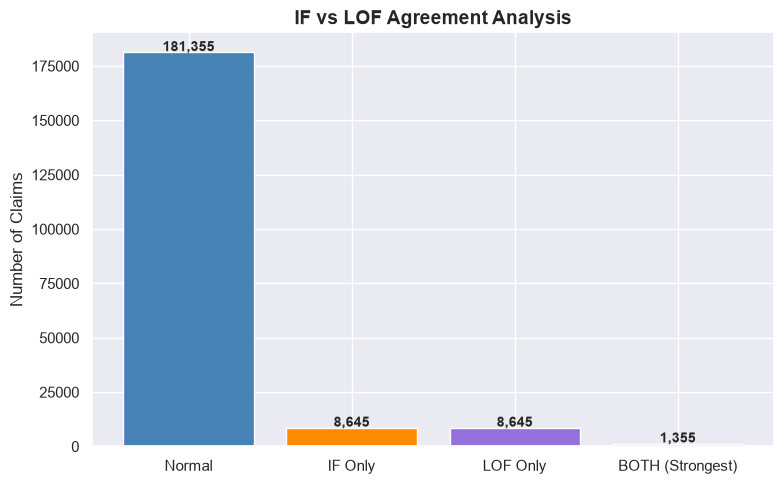


Crosstab (IF rows vs LOF cols):


LOF,0,1,All
IF,,,
0,181355,8645,190000
1,8645,1355,10000
All,190000,10000,200000


In [11]:
# Agreement categories
claim_df['consensus'] = 'Normal'
claim_df.loc[(claim_df['if_flag']==1) & (claim_df['lof_flag']==0), 'consensus'] = 'IF Only'
claim_df.loc[(claim_df['if_flag']==0) & (claim_df['lof_flag']==1), 'consensus'] = 'LOF Only'
claim_df.loc[(claim_df['if_flag']==1) & (claim_df['lof_flag']==1), 'consensus'] = 'BOTH (Strongest)'

agreement_counts = claim_df['consensus'].value_counts()
print("=== Agreement Table ===")
print(agreement_counts.to_string())
print()
print("Strongest candidates (flagged by BOTH):",
      (claim_df['consensus'] == 'BOTH (Strongest)').sum(),
      f"({(claim_df['consensus'] == 'BOTH (Strongest)').mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 5))
colors = {'Normal':'steelblue','IF Only':'darkorange',
          'LOF Only':'mediumpurple','BOTH (Strongest)':'crimson'}
bars = ax.bar(agreement_counts.index, agreement_counts.values,
              color=[colors[k] for k in agreement_counts.index], edgecolor='white')
ax.set_title("IF vs LOF Agreement Analysis")
ax.set_ylabel("Number of Claims")
for bar, val in zip(bars, agreement_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig("..\\anomaly_detect_images\s8_agreement.png", dpi=100, bbox_inches='tight')
plt.show()

# Cross-tab
print()
ct = pd.crosstab(claim_df['if_flag'], claim_df['lof_flag'],
                 rownames=['IF'], colnames=['LOF'],
                 margins=True)
print("Crosstab (IF rows vs LOF cols):")
display(ct)


---
## 9. Anomaly Investigation — Profile of Flagged Claims <a id='9'></a>

In [12]:
# Compare flagged vs normal across key dimensions
both_flagged = claim_df['consensus'] == 'BOTH (Strongest)'
normal       = claim_df['consensus'] == 'Normal'

compare_cols = ['claim_amount','payment_ratio','settlement_days',
                'duplicate_claim_flag','predicted_provider_risk','predicted_patient_risk']

print("=== ANOMALY PROFILE: BOTH-flagged vs Normal ===")
rows = []
for col in compare_cols:
    both_mean   = claim_df.loc[both_flagged, col].mean()
    normal_mean = claim_df.loc[normal,       col].mean()
    pct_diff    = (both_mean - normal_mean) / (abs(normal_mean) + 1e-9) * 100
    rows.append({'Feature': col,
                 'BOTH_flagged_mean': round(both_mean,4),
                 'Normal_mean': round(normal_mean,4),
                 'Pct_diff': round(pct_diff,1)})

profile_df = pd.DataFrame(rows)
display(profile_df)


=== ANOMALY PROFILE: BOTH-flagged vs Normal ===


,Feature,BOTH_flagged_mean,Normal_mean,Pct_diff
0,claim_amount,36412.5863,25295.0462,44.0
1,payment_ratio,0.8286,0.8973,-7.7
2,settlement_days,77.2687,-13.6316,666.8
3,duplicate_claim_flag,0.0000,0.0000,0.0
4,predicted_provider_risk,0.1328,0.1062,25.0
5,predicted_patient_risk,0.2542,0.2036,24.8


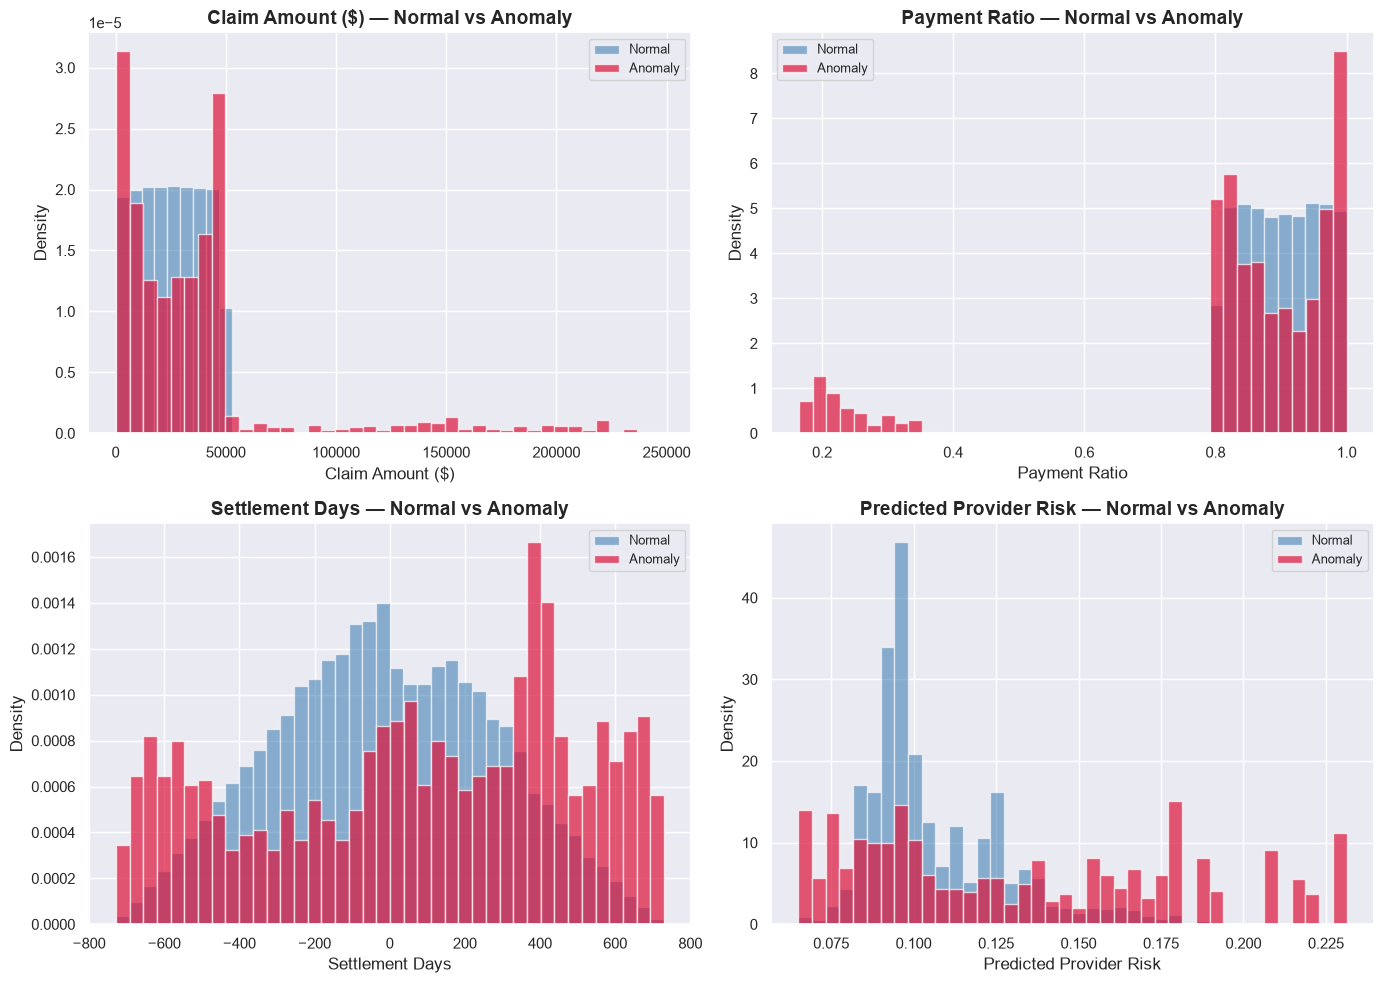

In [13]:
# Visual comparison: 4-panel anomaly profile
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_pairs = [
    ('claim_amount',            'Claim Amount ($)'),
    ('payment_ratio',           'Payment Ratio'),
    ('settlement_days',         'Settlement Days'),
    ('predicted_provider_risk', 'Predicted Provider Risk'),
]

for ax, (col, label) in zip(axes.flatten(), plot_pairs):
    data_normal = claim_df.loc[normal, col].dropna()
    data_flagged= claim_df.loc[both_flagged, col].dropna()

    ax.hist(data_normal,  bins=40, alpha=0.6, color='steelblue', label='Normal',   density=True)
    ax.hist(data_flagged, bins=40, alpha=0.7, color='crimson',   label='Anomaly',  density=True)
    ax.set_title(f"{label} — Normal vs Anomaly")
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("..\\anomaly_detect_images\s9_anomaly_profiles.png", dpi=100, bbox_inches='tight')
plt.show()


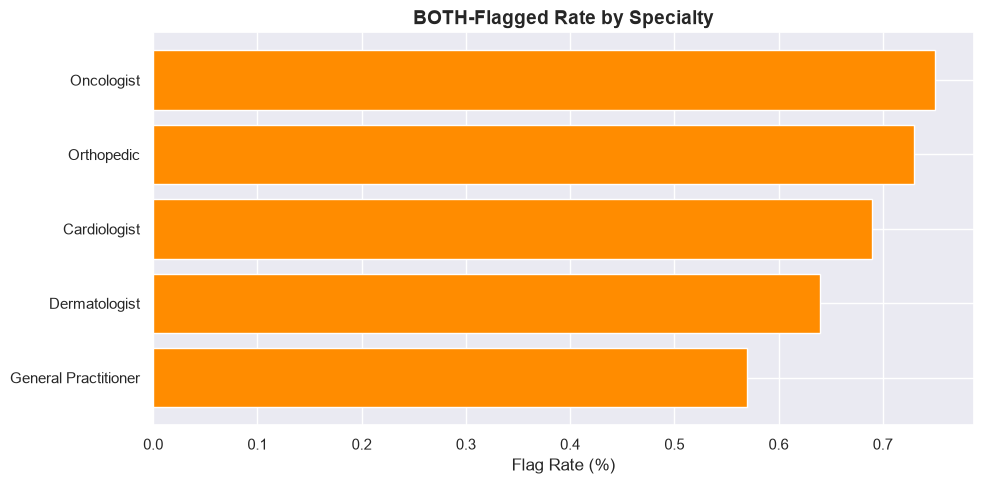

           specialty  total_claims  both_flagged  flag_rate_pct
          Oncologist         41004           309           0.75
          Orthopedic         40989           298           0.73
        Cardiologist         38552           266           0.69
       Dermatologist         38606           249           0.64
General Practitioner         40849           233           0.57


In [14]:
# Specialty breakdown of flagged claims
specialty_flag_rate = (
    claim_df.groupby('specialty')
    .agg(total_claims=('claim_id','count'),
         both_flagged=('if_flag', lambda x: ((claim_df.loc[x.index,'consensus']=='BOTH (Strongest)')).sum()))
    .reset_index()
)
specialty_flag_rate['flag_rate_pct'] = (
    specialty_flag_rate['both_flagged'] / specialty_flag_rate['total_claims'] * 100
).round(2)
specialty_flag_rate = specialty_flag_rate.sort_values('flag_rate_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(specialty_flag_rate['specialty'], specialty_flag_rate['flag_rate_pct'],
        color='darkorange', edgecolor='white')
ax.set_title("BOTH-Flagged Rate by Specialty")
ax.set_xlabel("Flag Rate (%)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("..\\anomaly_detect_images\s9_specialty_flag_rate.png", dpi=100, bbox_inches='tight')
plt.show()
print(specialty_flag_rate.to_string(index=False))


---
## 10. Suspicious Claim Score (0–100) <a id='10'></a>

We combine three independent signals into a single ranked score:

```
suspicious_claim_score =
    0.40 × predicted_provider_risk  (normalized 0-1)
  + 0.30 × predicted_patient_risk   (normalized 0-1)
  + 0.30 × if_anomaly_percentile    (normalized 0-1, inverted)
```

Normalized to 0–100 for business readability.


Suspicious Claim Score stats (0–100):
count    200000.00
mean         27.59
std           9.46
min           9.51
25%          20.59
50%          25.90
75%          32.53
max          89.61


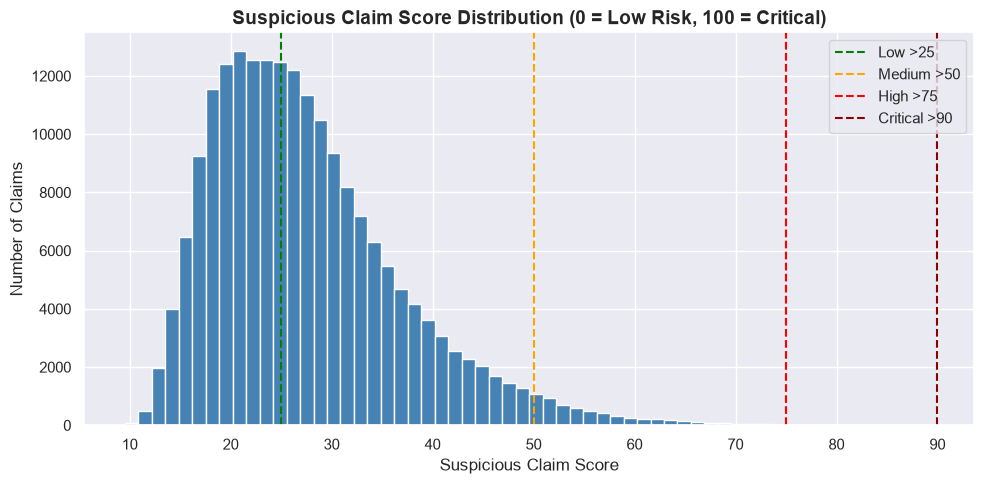

In [15]:
from sklearn.preprocessing import MinMaxScaler

# Isolation Forest score: lower = more anomalous → invert so higher = more suspicious
claim_df['if_anomaly_inverted'] = -claim_df['if_anomaly_score']

mm = MinMaxScaler()
claim_df['if_norm']   = mm.fit_transform(claim_df[['if_anomaly_inverted']])
claim_df['prov_norm'] = mm.fit_transform(claim_df[['predicted_provider_risk']])
claim_df['pat_norm']  = mm.fit_transform(claim_df[['predicted_patient_risk']])

claim_df['suspicious_claim_score'] = (
    0.40 * claim_df['prov_norm'] +
    0.30 * claim_df['pat_norm']  +
    0.30 * claim_df['if_norm']
) * 100  # scale to 0–100

print("Suspicious Claim Score stats (0–100):")
print(claim_df['suspicious_claim_score'].describe().round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(claim_df['suspicious_claim_score'], bins=60, color='steelblue', edgecolor='white')
ax.set_title("Suspicious Claim Score Distribution (0 = Low Risk, 100 = Critical)")
ax.set_xlabel("Suspicious Claim Score")
ax.set_ylabel("Number of Claims")
for threshold, color, label in [(25,'green','Low'),  (50,'orange','Medium'),
                                  (75,'red','High'),   (90,'darkred','Critical')]:
    ax.axvline(threshold, color=color, linestyle='--', linewidth=1.5, label=f'{label} >{threshold}')
ax.legend()
plt.tight_layout()
plt.savefig("..\\anomaly_detect_images\s10_suspicious_score.png", dpi=100, bbox_inches='tight')
plt.show()


---
## 11. Investigation Buckets <a id='11'></a>

=== INVESTIGATION BUCKETS ===
  Low Risk    :  91,597 claims (45.8%)
  Medium Risk : 102,770 claims (51.4%)
  High Risk   :   5,570 claims (2.8%)
  Critical    :      63 claims (0.0%)


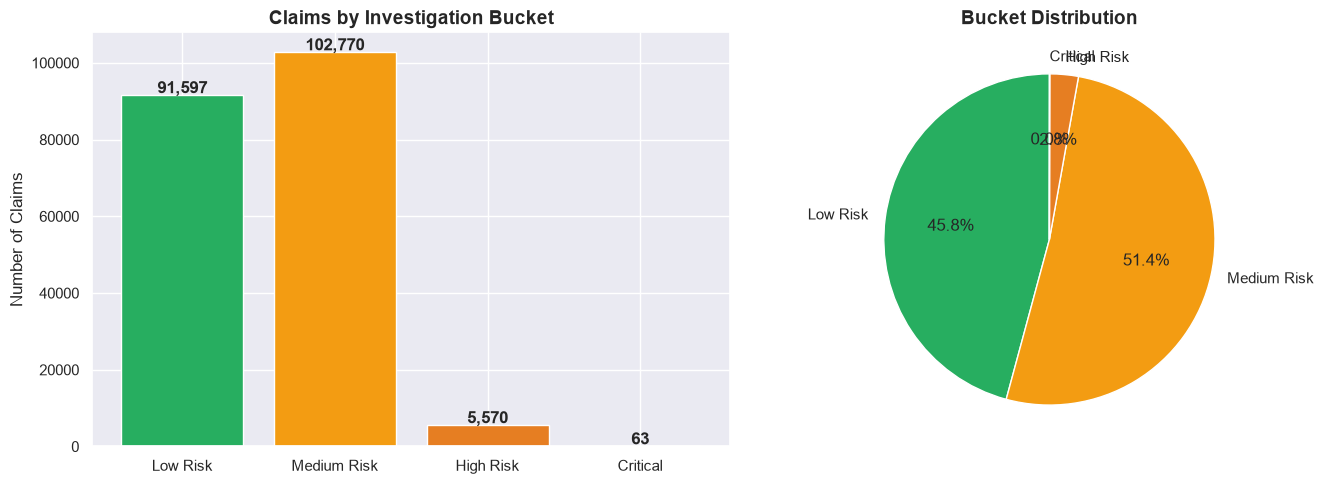


Top 20 Critical claims:


,claim_id,patient_id,provider_id,specialty,claim_amount,payment_ratio,duplicate_claim_flag,suspicious_claim_score,consensus
0,43569,28148,1621,Oncologist,24954.000000,NaN,0,89.612763,BOTH (Strongest)
1,91787,40824,4637,Orthopedic,45875.000000,0.8734,0,87.601641,BOTH (Strongest)
2,130651,32590,3102,General Practitioner,39374.000000,NaN,0,87.513356,BOTH (Strongest)
3,96870,46601,3055,Orthopedic,219566.060094,0.1989,0,84.258997,BOTH (Strongest)
4,127458,4433,4,Orthopedic,33808.000000,0.9246,0,83.308739,BOTH (Strongest)
5,80236,29827,3055,Orthopedic,220811.388981,0.1846,0,82.397713,BOTH (Strongest)
6,107192,25355,3102,General Practitioner,48543.000000,0.8736,0,81.930514,BOTH (Strongest)
7,134598,21473,3055,Orthopedic,11776.000000,0.8462,0,81.927186,BOTH (Strongest)
8,58125,46904,4268,Orthopedic,17661.000000,0.9271,0,81.522812,BOTH (Strongest)
9,33882,33002,4637,Orthopedic,136075.653060,0.2484,0,81.504066,BOTH (Strongest)


In [16]:
def assign_bucket(score):
    if score <= 25:   return 'Low Risk'
    elif score <= 50: return 'Medium Risk'
    elif score <= 75: return 'High Risk'
    else:             return 'Critical'

claim_df['risk_bucket'] = claim_df['suspicious_claim_score'].apply(assign_bucket)

bucket_order  = ['Low Risk', 'Medium Risk', 'High Risk', 'Critical']
bucket_counts = claim_df['risk_bucket'].value_counts().reindex(bucket_order)
bucket_colors = ['#27AE60','#F39C12','#E67E22','#E74C3C']

print("=== INVESTIGATION BUCKETS ===")
for bucket, count in bucket_counts.items():
    pct = count / len(claim_df) * 100
    print(f"  {bucket:12s}: {count:7,} claims ({pct:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(bucket_counts.index, bucket_counts.values,
            color=bucket_colors, edgecolor='white')
axes[0].set_title("Claims by Investigation Bucket")
axes[0].set_ylabel("Number of Claims")
for i, (_, val) in enumerate(bucket_counts.items()):
    axes[0].text(i, val+500, f'{val:,}', ha='center', fontweight='bold')

axes[1].pie(bucket_counts.values, labels=bucket_counts.index,
            colors=bucket_colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title("Bucket Distribution")

plt.tight_layout()
plt.savefig("..\\anomaly_detect_images\s11_buckets.png", dpi=100, bbox_inches='tight')
plt.show()

print()
print("Top 20 Critical claims:")
display(claim_df[claim_df['risk_bucket']=='Critical']
        .nlargest(20,'suspicious_claim_score')
        [['claim_id','patient_id','provider_id','specialty','claim_amount',
          'payment_ratio','duplicate_claim_flag','suspicious_claim_score','consensus']]
        .reset_index(drop=True))


---
## 12. Validation Without Labels <a id='12'></a>

Since there are no fraud labels, we validate the anomaly detector using
**business logic**: if our flagged claims are enriched with known fraud
indicators (duplicates, large payment gaps, risky providers), the detector
is discovering meaningful suspicious behavior — not random noise.


In [17]:
validation_checks = {}

# Check 1: Duplicate claim enrichment
dup_rate_anomaly = claim_df.loc[both_flagged, 'duplicate_claim_flag'].mean()
dup_rate_normal  = claim_df.loc[normal,       'duplicate_claim_flag'].mean()
validation_checks['Duplicate Rate'] = {
    'Anomaly': dup_rate_anomaly, 'Normal': dup_rate_normal,
    'Enriched': dup_rate_anomaly > dup_rate_normal
}

# Check 2: Payment gap enrichment
gap_anomaly = claim_df.loc[both_flagged, 'payment_gap'].mean()
gap_normal  = claim_df.loc[normal,       'payment_gap'].mean()
validation_checks['Avg Payment Gap'] = {
    'Anomaly': gap_anomaly, 'Normal': gap_normal,
    'Enriched': gap_anomaly > gap_normal
}

# Check 3: Provider risk enrichment
pr_anomaly = claim_df.loc[both_flagged, 'predicted_provider_risk'].mean()
pr_normal  = claim_df.loc[normal,       'predicted_provider_risk'].mean()
validation_checks['Avg Provider Risk'] = {
    'Anomaly': pr_anomaly, 'Normal': pr_normal,
    'Enriched': pr_anomaly > pr_normal
}

# Check 4: Rejection rate enrichment
rej_anomaly = claim_df.loc[both_flagged, 'rejected_flag'].mean()
rej_normal  = claim_df.loc[normal,       'rejected_flag'].mean()
validation_checks['Rejection Rate'] = {
    'Anomaly': rej_anomaly, 'Normal': rej_normal,
    'Enriched': rej_anomaly > rej_normal
}

# Check 5: Late payment enrichment
late_anomaly = claim_df.loc[both_flagged, 'late_payment_flag'].mean()
late_normal  = claim_df.loc[normal,       'late_payment_flag'].mean()
validation_checks['Late Payment Rate'] = {
    'Anomaly': late_anomaly, 'Normal': late_normal,
    'Enriched': late_anomaly > late_normal
}

val_df = pd.DataFrame(validation_checks).T.reset_index().rename(columns={'index':'Metric'})
val_df['Anomaly'] = val_df['Anomaly'].round(4)
val_df['Normal']  = val_df['Normal'].round(4)
val_df['Result']  = val_df['Enriched'].map({True: 'CONFIRMED', False: 'Not confirmed'})

print("="*60)
print("  VALIDATION WITHOUT LABELS — BUSINESS LOGIC CHECKS")
print("="*60)
display(val_df[['Metric','Anomaly','Normal','Result']])

confirmed = val_df['Enriched'].sum()
total     = len(val_df)
print(f"\n{confirmed}/{total} checks confirmed.")
if confirmed >= 3:
    print("Conclusion: anomaly detector is capturing MEANINGFUL suspicious")
    print("behavior, not random noise.")
else:
    print("Conclusion: anomaly detector needs further tuning.")


  VALIDATION WITHOUT LABELS — BUSINESS LOGIC CHECKS


,Metric,Anomaly,Normal,Result
0,Duplicate Rate,0.0,0.0,Not confirmed
1,Avg Payment Gap,15325.2941,8741.1143,CONFIRMED
2,Avg Provider Risk,0.1328,0.1062,CONFIRMED
3,Rejection Rate,0.414,0.1796,CONFIRMED
4,Late Payment Rate,0.3063,0.0765,CONFIRMED



True/5 checks confirmed.
Conclusion: anomaly detector needs further tuning.


---
## 13. Save Results <a id='13'></a>

In [18]:
output_cols = [
    'claim_id', 'patient_id', 'provider_id', 'specialty', 'claim_date',
    'claim_amount', 'payment_ratio', 'settlement_days',
    'duplicate_claim_flag', 'month_end_flag',
    'early_payment_flag', 'late_payment_flag', 'rejected_flag',
    'predicted_provider_risk', 'predicted_patient_risk',
    'if_flag', 'if_anomaly_score',
    'lof_flag', 'lof_anomaly_score',
    'consensus',
    'suspicious_claim_score',
    'risk_bucket'
]

suspicious_df = claim_df[output_cols].sort_values(
    'suspicious_claim_score', ascending=False
).reset_index(drop=True)

suspicious_df.to_csv("..\\anomaly_claim_data\suspicious_claims.csv", index=False)

print(f"suspicious_claims.csv saved: {suspicious_df.shape}")
print()
print("Columns:")
for c in output_cols:
    print(f"  {c}")
print()
print("Bucket breakdown in saved file:")
print(suspicious_df['risk_bucket'].value_counts().reindex(bucket_order).to_string())


suspicious_claims.csv saved: (200000, 22)

Columns:
  claim_id
  patient_id
  provider_id
  specialty
  claim_date
  claim_amount
  payment_ratio
  settlement_days
  duplicate_claim_flag
  month_end_flag
  early_payment_flag
  late_payment_flag
  rejected_flag
  predicted_provider_risk
  predicted_patient_risk
  if_flag
  if_anomaly_score
  lof_flag
  lof_anomaly_score
  consensus
  suspicious_claim_score
  risk_bucket

Bucket breakdown in saved file:
risk_bucket
Low Risk        91597
Medium Risk    102770
High Risk        5570
Critical           63


---
## 14. Summary <a id='14'></a>

In [19]:
print("="*70)
print("  07_ANOMALY_DETECTION -- SUMMARY")
print("="*70)

print()
print("DETECTION LEVEL: Claim-level (1 row = 1 claim)")
print(f"TOTAL CLAIMS SCORED: {len(claim_df):,}")
print()
print("BASELINE STATISTICAL OUTLIERS")
print(f"  claim_amount Z-score outliers  : {claim_df['zscore_outlier'].sum():,}")
print(f"  settlement_days IQR outliers   : {claim_df['iqr_outlier'].sum():,}")
print()
print("MODEL RESULTS")
print(f"  Isolation Forest flagged : {claim_df['if_flag'].sum():,} ({claim_df['if_flag'].mean()*100:.1f}%)")
print(f"  LOF flagged              : {claim_df['lof_flag'].sum():,} ({claim_df['lof_flag'].mean()*100:.1f}%)")
print(f"  BOTH flagged (consensus) : {(claim_df['consensus']=='BOTH (Strongest)').sum():,} "
      f"({(claim_df['consensus']=='BOTH (Strongest)').mean()*100:.1f}%)")
print()
print("INVESTIGATION BUCKETS (suspicious_claim_score 0-100)")
for bucket, count in bucket_counts.items():
    print(f"  {bucket:12s}: {count:7,} ({count/len(claim_df)*100:.1f}%)")
print()
print("VALIDATION (business logic checks)")
for _, row in val_df.iterrows():
    print(f"  {row['Metric']:22s}: {row['Result']}")
print()
print("ARTIFACT SAVED")
print("  suspicious_claims.csv -- all claims scored and bucketed")
print()
print("NEXT STEPS")
print("  08_Explainable_AI_and_LLM_Insights.ipynb")
print("  - Load suspicious_claims.csv (Critical bucket first)")
print("  - For each flagged claim, pass features to an LLM with a structured")
print("    prompt: 'Why is claim C101 suspicious?'")
print("  - Output: plain-English investigation narrative per claim")
print("  - Input to insurance investigators -- no ML knowledge required")


  07_ANOMALY_DETECTION -- SUMMARY

DETECTION LEVEL: Claim-level (1 row = 1 claim)
TOTAL CLAIMS SCORED: 200,000

BASELINE STATISTICAL OUTLIERS
  claim_amount Z-score outliers  : 1,167
  settlement_days IQR outliers   : 0

MODEL RESULTS
  Isolation Forest flagged : 10,000 (5.0%)
  LOF flagged              : 10,000 (5.0%)
  BOTH flagged (consensus) : 1,355 (0.7%)

INVESTIGATION BUCKETS (suspicious_claim_score 0-100)
  Low Risk    :  91,597 (45.8%)
  Medium Risk : 102,770 (51.4%)
  High Risk   :   5,570 (2.8%)
  Critical    :      63 (0.0%)

VALIDATION (business logic checks)
  Duplicate Rate        : Not confirmed
  Avg Payment Gap       : CONFIRMED
  Avg Provider Risk     : CONFIRMED
  Rejection Rate        : CONFIRMED
  Late Payment Rate     : CONFIRMED

ARTIFACT SAVED
  suspicious_claims.csv -- all claims scored and bucketed

NEXT STEPS
  08_Explainable_AI_and_LLM_Insights.ipynb
  - Load suspicious_claims.csv (Critical bucket first)
  - For each flagged claim, pass features to an LLM w